# librerias

In [71]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [72]:
np.random.seed(42)
tf.random.set_seed(42)

## Cargar datos

In [73]:
main_path='C:/Users/Samuel/Desktop/Redes_neuronales/Radiografias/chest_xray'
train_dir = os.path.join(main_path, 'train')
val_dir = os.path.join(main_path, 'val')
test_dir = os.path.join(main_path, 'test')

#### Crear dataframes para analizar datos

In [74]:
def create_dataframe(path, labels):
    data = []
    valid_ext = ('.jpg', '.jpeg', '.png')

    for label in labels:
        category_path = os.path.join(path, label)

        for file_name in os.listdir(category_path):
            if file_name.lower().endswith(valid_ext):  # 🔥 filtro clave
                file_path = os.path.join(category_path, file_name)

                data.append({
                    'file_path': file_path,
                    'label': label
                })

    return pd.DataFrame(data)

In [75]:
labels = ['NORMAL', 'PNEUMONIA']

train_df = create_dataframe(train_dir, labels)
test_df = create_dataframe(test_dir, labels)
val_df = create_dataframe(val_dir, labels)

In [76]:
train_df['label'] = train_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1})
val_df['label'] = val_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1})
test_df['label'] = test_df['label'].map({'NORMAL': 0, 'PNEUMONIA': 1})

In [77]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

def df_to_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices(
        (df['file_path'].values, df['label'].values)
    )
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

train_ds = df_to_dataset(train_df)
val_ds = df_to_dataset(val_df)
test_ds = df_to_dataset(test_df)

In [78]:
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

Los datos de validación son pequeños, constan de 16 imágenes. Por lo tanto, combinaremos los conjuntos de datos de entrenamiento, validación y prueba,dividiremos los datos en una proporción de 70:15:15: 70% para el entrenamiento, 15% para la validación y 15% para el conjunto de prueba.

In [79]:

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

In [80]:
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(4172, 2)
(624, 2)
(1044, 2)


## Exploracion de los datos

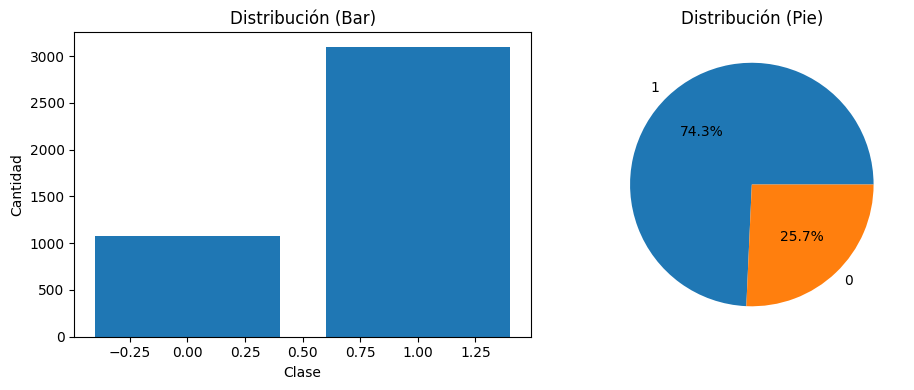

In [81]:
labels_count = train_df['label'].value_counts()

plt.figure(figsize=(10,4))

# Bar chart
plt.subplot(1,2,1)
plt.bar(labels_count.index, labels_count.values)
plt.title("Distribución (Bar)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

# Pie chart
plt.subplot(1,2,2)
plt.pie(labels_count.values, labels=labels_count.index, autopct='%1.1f%%')
plt.title("Distribución (Pie)")

plt.tight_layout()
plt.show()

In [82]:
from PIL import Image

def plot_images(image_paths, label, nrows=2, ncols=5):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 7))
    num_images = nrows * ncols

    for i in range(num_images):
        img = Image.open(image_paths[i])
        row_idx, col_idx = divmod(i, ncols)

        axes[row_idx, col_idx].imshow(img, cmap='gray')
        axes[row_idx, col_idx].axis('off')
        axes[row_idx, col_idx].set_title(f'{label}\nShape: {img.size}')

    plt.show()


# ✅ CORRECCIÓN AQUÍ
pneumonia_path = train_df[train_df['label'] == 1]['file_path'].values
normal_path = train_df[train_df['label'] == 0]['file_path'].values

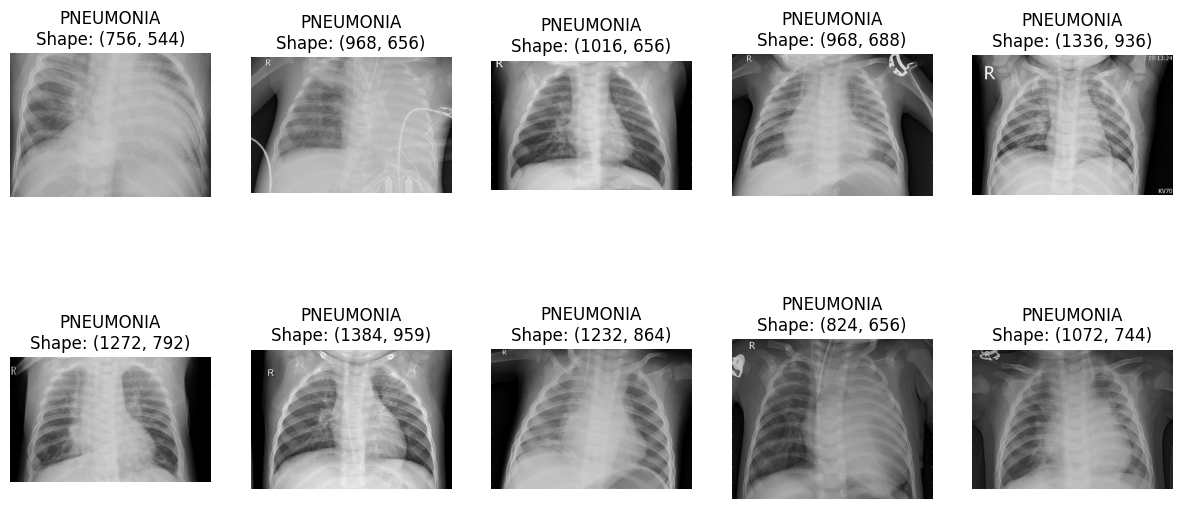

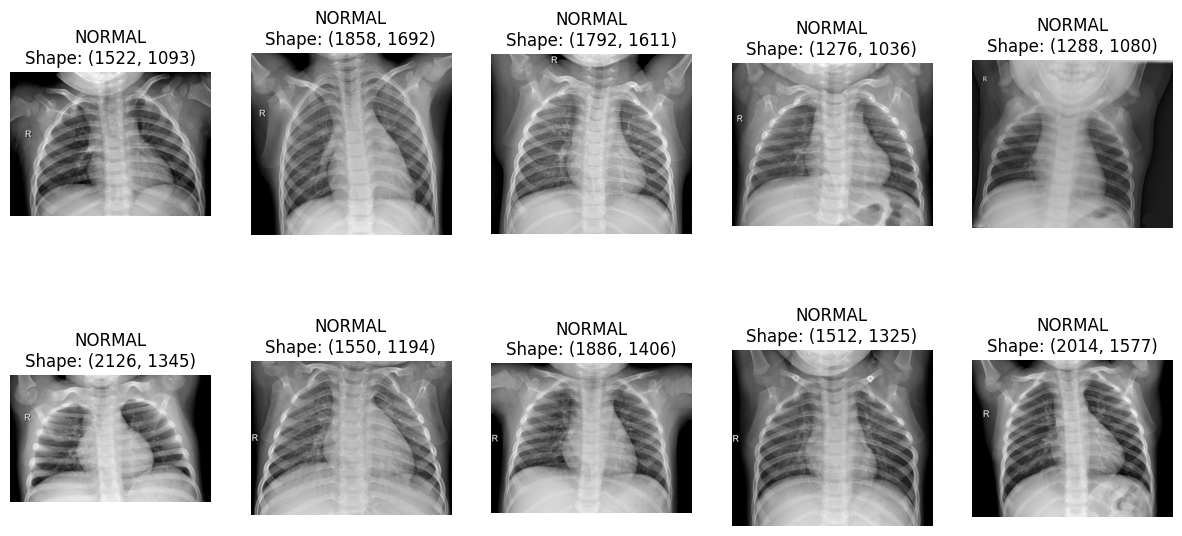

In [83]:
plot_images(pneumonia_path, "PNEUMONIA")
plot_images(normal_path, "NORMAL")

A partir de los resultados de la visualización, podemos observar que:
- Varias imágenes tienden a estar inclinadas hacia la derecha o la izquierda.

- Varias imágenes muestran manos y barbillas.

- Varias imágenes parecen estar recortadas, como se aprecia en su tamaño inferior a 10 kb.

- Varias imágenes presentan un grado de claridad y oscuridad variables.

Con base en estos resultados, en la sección de preprocesamiento, parece necesario aumentar la rotación aleatoria, el zoom y posiblemente la variación de color.

### Procesamiento de imagenes

In [84]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

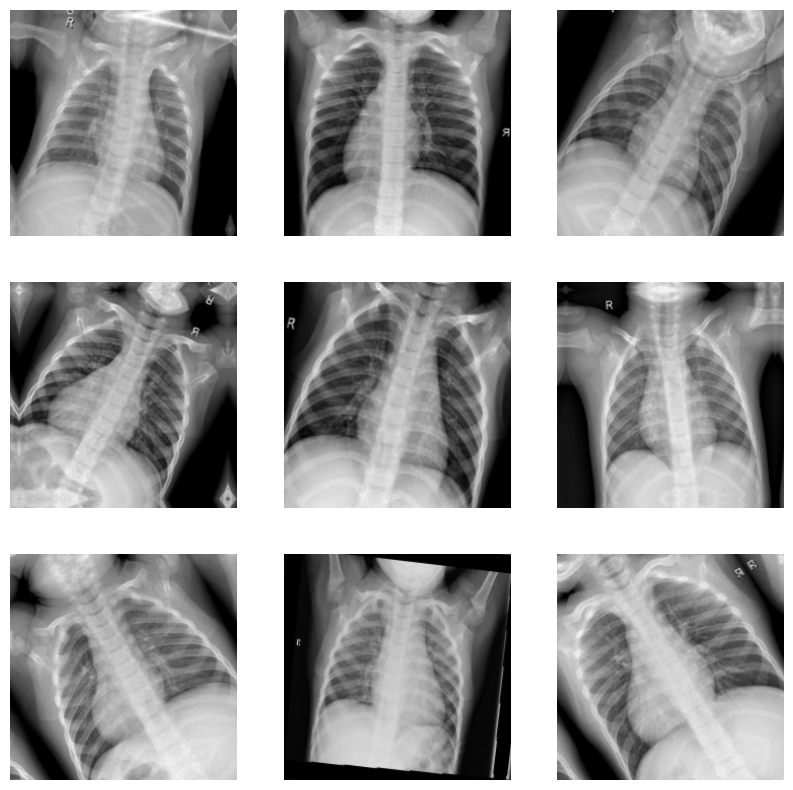

In [85]:

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        augmented_image = data_augmentation(images[i])
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy())
        plt.axis("off")

In [87]:
train_ds = df_to_dataset(train_df)

train_ds_base = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

train_ds_augmented = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

# Modelo

## CNN: Comparación con y sin Data Augmentation


In [98]:

def create_model():
    model = keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [100]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

callbacks = [early_stop, reduce_lr]

Entrenamiento sin aumentacion

In [101]:
model_base = create_model()

history_base = model_base.fit(
    train_ds_base,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 363ms/step - accuracy: 0.8512 - loss: 0.3235 - val_accuracy: 0.7500 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 373ms/step - accuracy: 0.9398 - loss: 0.1581 - val_accuracy: 0.8125 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 358ms/step - accuracy: 0.9477 - loss: 0.1397 - val_accuracy: 0.8750 - val_loss: 0.2541 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.9626 - loss: 0.1052 - val_accuracy: 0.9375 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 338ms/step - accuracy: 0.9698 - loss: 0.0829 - val_accuracy: 0.9375 - val_loss: 0.1520 - learning_rate: 0.0010
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 340ms/step - accuracy: 0.9739 - loss: 0.0762 - val_accuracy: 1.0000 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 336ms/step - accuracy: 0.9

Entrenamiento con aumentacion

In [102]:
model_aug = create_model()

history_aug = model_aug.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 357ms/step - accuracy: 0.7565 - loss: 0.5105 - val_accuracy: 0.5000 - val_loss: 0.9202 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 369ms/step - accuracy: 0.8382 - loss: 0.3366 - val_accuracy: 0.7500 - val_loss: 0.8153 - learning_rate: 0.0010


Notas: - **`EarlyStopping`**: Monitorea el valor de 'val_loss' en cada época. El entrenamiento se detendrá si 'val_loss' no mejora en 3 épocas consecutivas. `restore_best_weights=True` restaura los pesos del modelo a la mejor iteración si se detiene el entrenamiento.

- **`ModelCheckpoint`**: Guarda el modelo con mejor rendimiento según 'val_loss' en el archivo 'model_best.h5'. `save_best_only=True` solo guarda el modelo si su rendimiento es mejor que el anterior.

- **`ReduceLROnPlateau`**: Reduce la tasa de aprendizaje en un factor de 0.2 si 'val_loss' no mejora en 2 épocas consecutivas. `min_lr=1e-7` establece el límite inferior para la tasa de aprendizaje.

Las funciones de devolución de llamada se utilizan para mejorar la eficiencia del entrenamiento, prevenir el sobreajuste y garantizar la retención del mejor modelo.

### Resultado Acuracy

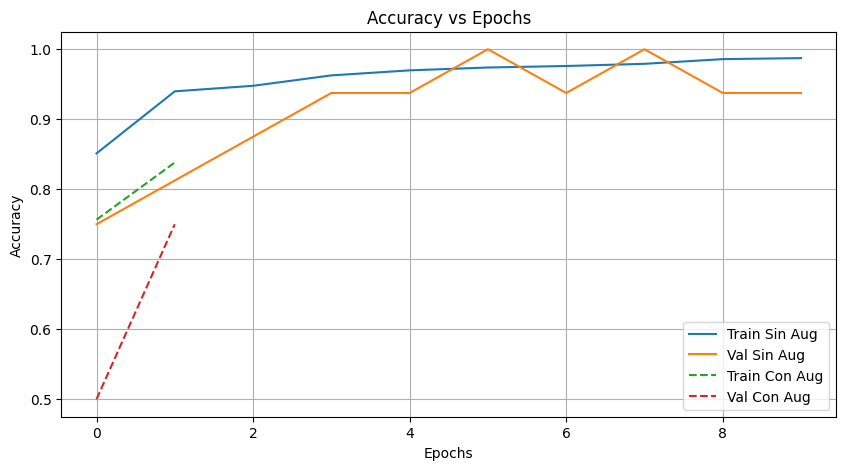

In [103]:
plt.figure(figsize=(10,5))

# Modelo sin augmentation
plt.plot(history_base.history['accuracy'], label='Train Sin Aug')
plt.plot(history_base.history['val_accuracy'], label='Val Sin Aug')

# Modelo con augmentation
plt.plot(history_aug.history['accuracy'], linestyle='--', label='Train Con Aug')
plt.plot(history_aug.history['val_accuracy'], linestyle='--', label='Val Con Aug')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

### Resultado LOSS

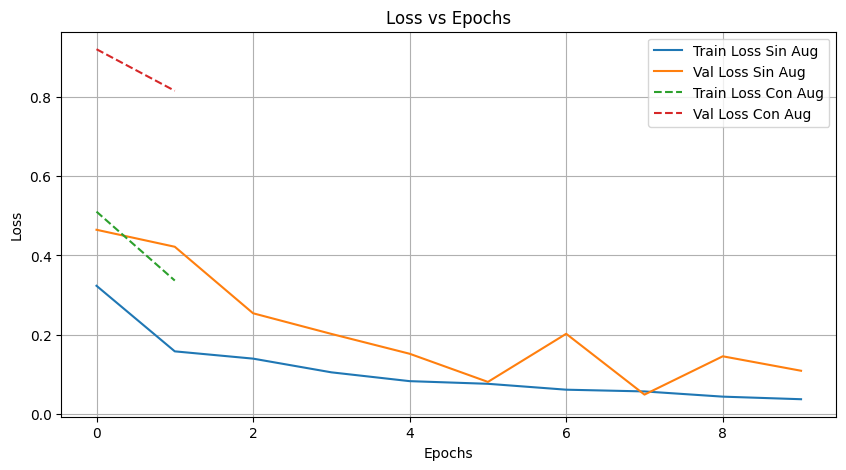

In [105]:
plt.figure(figsize=(10,5))

# Modelo sin augmentation
plt.plot(history_base.history['loss'], label='Train Loss Sin Aug')
plt.plot(history_base.history['val_loss'], label='Val Loss Sin Aug')

# Modelo con augmentation
plt.plot(history_aug.history['loss'], linestyle='--', label='Train Loss Con Aug')
plt.plot(history_aug.history['val_loss'], linestyle='--', label='Val Loss Con Aug')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [106]:
loss_base, acc_base = model_base.evaluate(test_ds)
loss_aug, acc_aug = model_aug.evaluate(test_ds)

print("=== RESULTADOS EN TEST ===\n")

print(f"Modelo SIN augmentation: {acc_base:.4f}")
print(f"Modelo CON augmentation: {acc_aug:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.7436 - loss: 1.4531 
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.6394 - loss: 0.6600
=== RESULTADOS EN TEST ===

Modelo SIN augmentation: 0.7436
Modelo CON augmentation: 0.6394


In [110]:
import requests

def download_image(url, filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)

image_url = 'https://prod-images-static.radiopaedia.org/images/220869/76052f7902246ff862f52f5d3cd9cd_big_gallery.jpg'
file_name = 'normal_xray.jpg'

download_image(image_url, file_name)

image_path_to_predict = file_name

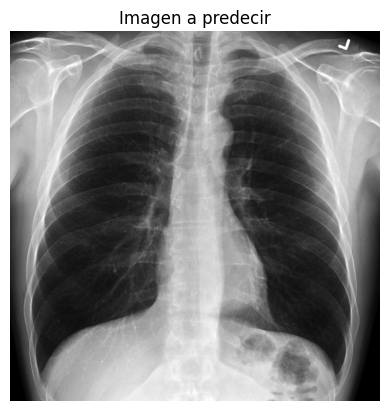

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
=== RESULTADOS ===

Modelo SIN augmentation:
Predicción: PNEUMONIA
Confianza: 0.7816

Modelo CON augmentation:
Predicción: PNEUMONIA
Confianza: 0.7930


In [116]:
import cv2


img = cv2.imread(image_path_to_predict)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Imagen a predecir")
plt.axis("off")
plt.show()

def predict_image(model, image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = img / 255.0
    
    img = tf.expand_dims(img, axis=0)  # batch
    
    prediction = model.predict(img)[0][0]
    
    if prediction > 0.5:
        return "PNEUMONIA", prediction
    else:
        return "NORMAL", 1 - prediction

# Modelo sin augmentation
pred_base, conf_base = predict_image(model_base, image_path_to_predict)

# Modelo con augmentation
pred_aug, conf_aug = predict_image(model_aug, image_path_to_predict)

print("=== RESULTADOS ===\n")

print("Modelo SIN augmentation:")
print(f"Predicción: {pred_base}")
print(f"Confianza: {conf_base:.4f}\n")

print("Modelo CON augmentation:")
print(f"Predicción: {pred_aug}")
print(f"Confianza: {conf_aug:.4f}")